In [1]:
# Подключаем библиотеки
import pandas as pd # Работа с набором данных
import numpy as np # Линейная алгебра
# Визуализация данных
import seaborn as sns
import matplotlib.pyplot as plt

# отключение информационных сообщений
from warnings import filterwarnings
filterwarnings(action='ignore')

In [2]:
# читаем данные
url = 'https://raw.githubusercontent.com/yakushinav/omo/refs/heads/main/data/transfusion.csv'
data = pd.read_csv(url)
data.head(5)

,Recency,Frequency,Monetary,Time,Donated_blood
0,2,50,12500,98,1
1,0,13,3250,28,1
2,1,16,4000,35,1
3,2,20,5000,45,1
4,1,24,6000,77,0


In [3]:
data.dtypes

,0
Recency,int64
Frequency,int64
Monetary,int64
Time,int64
Donated_blood,int64


In [4]:
data.describe()

,Recency,Frequency,Monetary,Time,Donated_blood
count,748.000000,748.000000,748.000000,748.000000,748.000000
mean,9.506684,5.514706,1378.676471,34.282086,0.237968
std,8.095396,5.839307,1459.826781,24.376714,0.426124
min,0.000000,1.000000,250.000000,2.000000,0.000000
25%,2.750000,2.000000,500.000000,16.000000,0.000000
50%,7.000000,4.000000,1000.000000,28.000000,0.000000
75%,14.000000,7.000000,1750.000000,50.000000,0.000000
max,74.000000,50.000000,12500.000000,98.000000,1.000000


<Axes: xlabel='Frequency', ylabel='Time'>

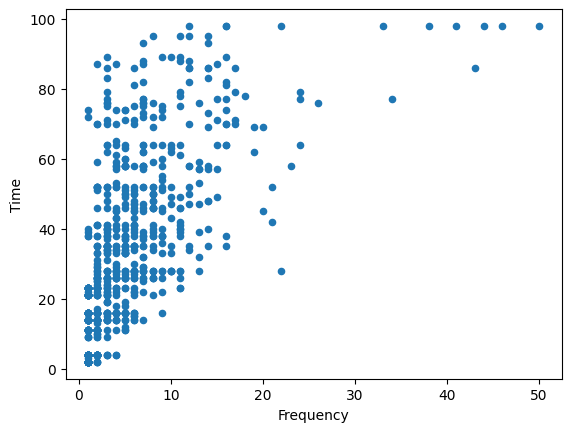

In [7]:
data.plot(kind='scatter',x='Frequency', y='Time')

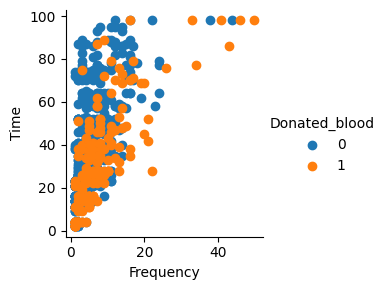

In [8]:
sns.FacetGrid(data, hue = 'Donated_blood') \
    .map(plt.scatter, 'Frequency','Time') \
    .add_legend()

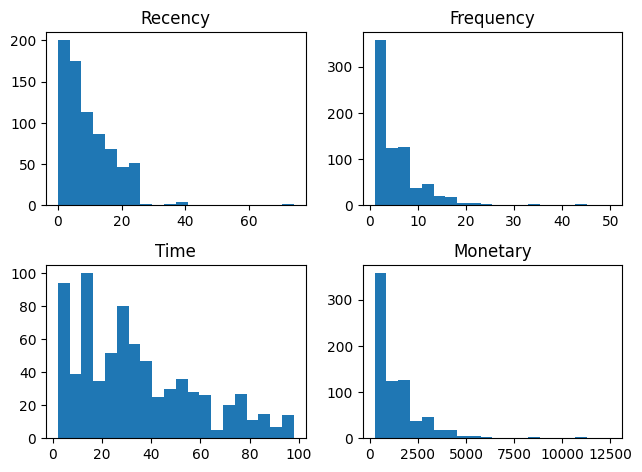

In [10]:
n_bins = 20
fig, axs = plt.subplots(2, 2)
axs[0,0].hist(data['Recency'], bins = n_bins);
axs[0,0].set_title('Recency');
axs[0,1].hist(data['Frequency'], bins = n_bins);
axs[0,1].set_title('Frequency');
axs[1,0].hist(data['Time'], bins = n_bins);
axs[1,0].set_title('Time');
axs[1,1].hist(data['Monetary'], bins = n_bins);
axs[1,1].set_title('Monetary');

fig.tight_layout(pad=1.0);

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 748 entries, 0 to 747
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Recency        748 non-null    int64
 1   Frequency      748 non-null    int64
 2   Monetary       748 non-null    int64
 3   Time           748 non-null    int64
 4   Donated_blood  748 non-null    int64
dtypes: int64(5)
memory usage: 29.3 KB


<Axes: xlabel='Donated_blood', ylabel='Frequency'>

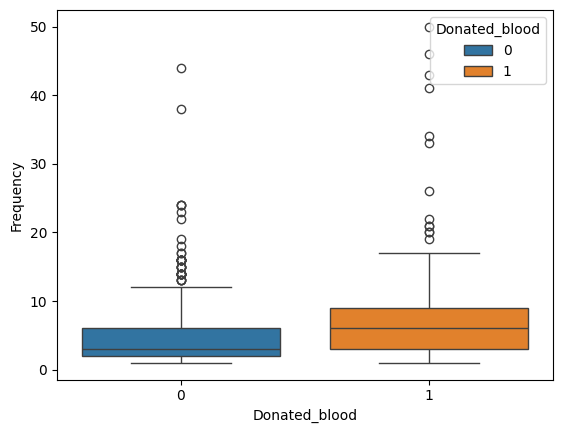

In [14]:
sns.boxplot(x='Donated_blood', y='Frequency', hue='Donated_blood', data=data)

<Axes: xlabel='Donated_blood', ylabel='Time'>

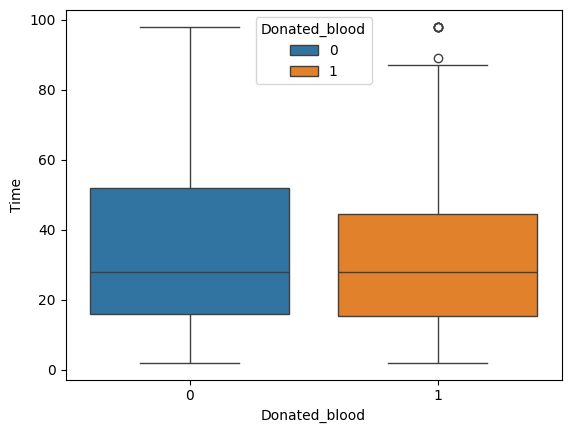

In [16]:
sns.boxplot(x='Donated_blood', y='Time', hue='Donated_blood', data=data)

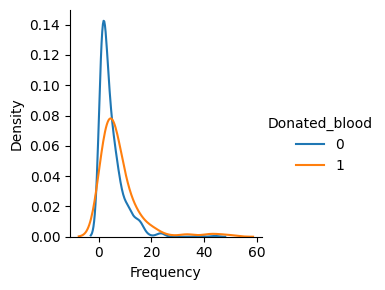

In [18]:
sns.FacetGrid(data, hue="Donated_blood") \
   .map(sns.kdeplot, "Frequency") \
   .add_legend()

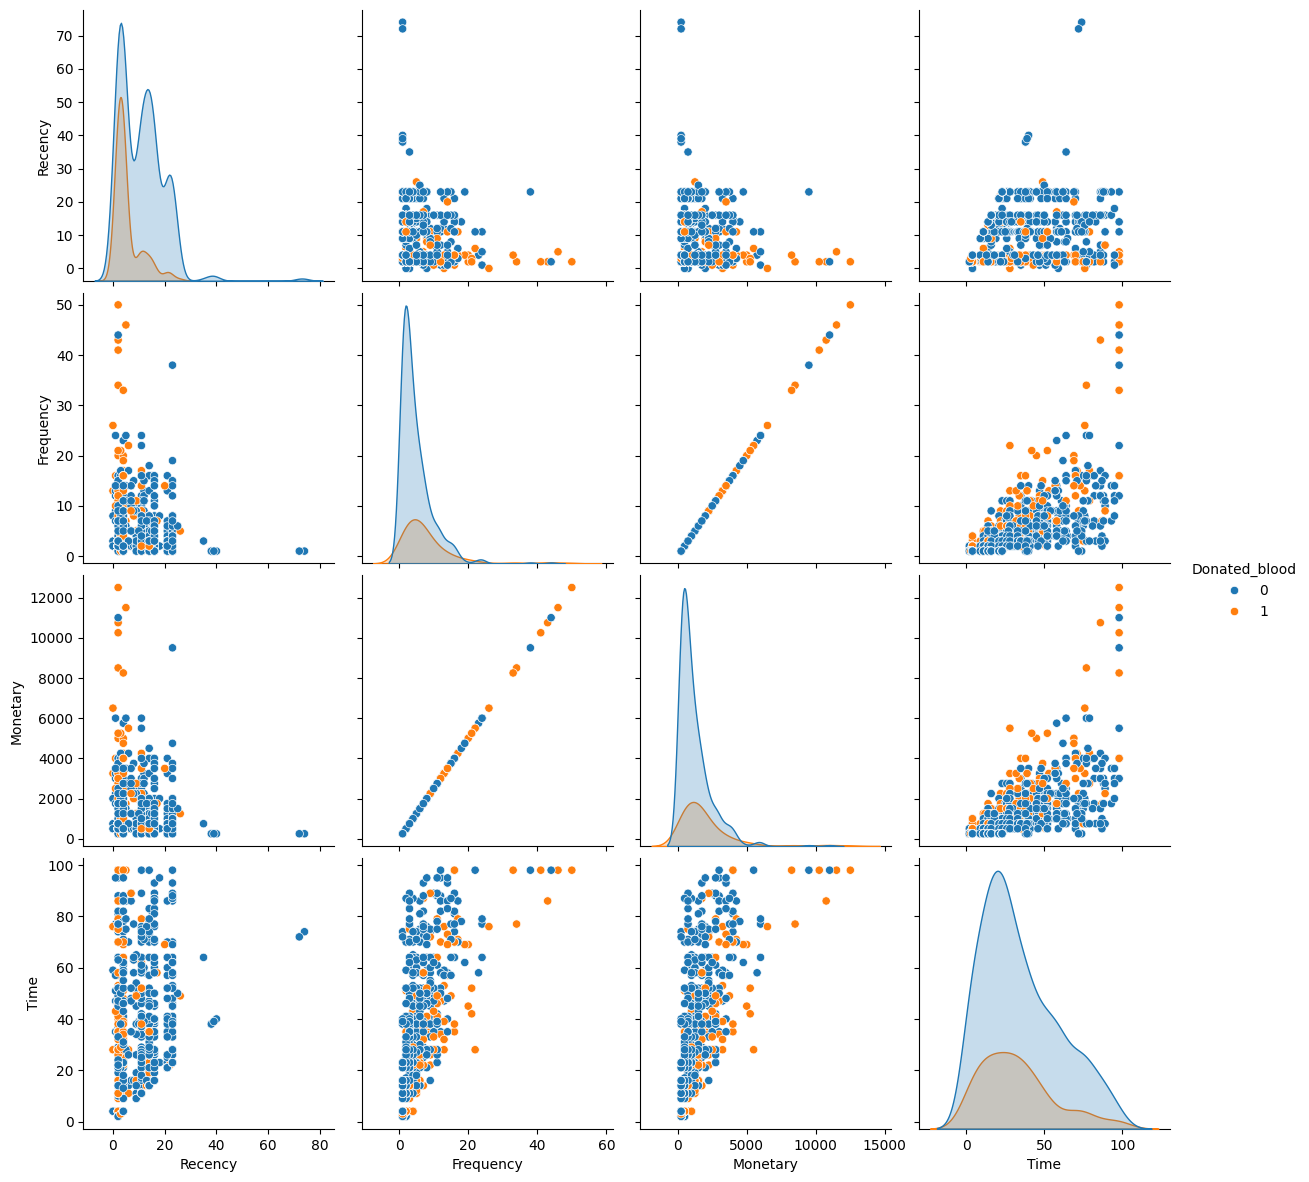

In [19]:
sns.pairplot(data, hue='Donated_blood', size=3)

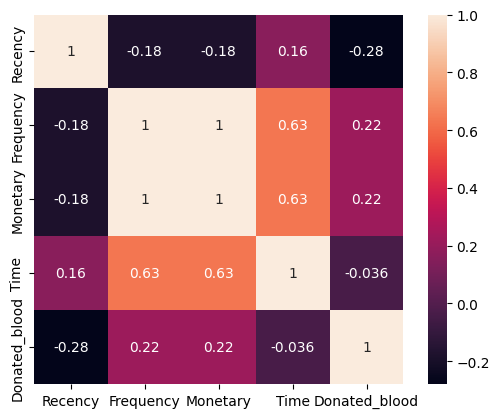

In [20]:
corrmat = data.corr(numeric_only=True)
sns.heatmap(corrmat, annot = True, square = True);

In [21]:
data.groupby('Donated_blood').size()

,0
Donated_blood,
0,570
1,178
